# Chapter 4: Linear Models of Returns

In [1]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
import matplotlib.pyplot as plt

## Data Prep and Generic Strategy

In [2]:
data_path = os.path.join(os.getcwd(), "data")

In [3]:
path = os.path.join(data_path, "RawPX.parquet")
df_raw = (pd
    .read_parquet(path = path, engine = "pyarrow")
    .loc[lambda x: x.Price == "Adj Close"]
    .dropna())

In [4]:
tickers = (df_raw
    [["date", "Ticker"]]
    .groupby("Ticker")
    .agg("min")
    .sort_values("date")
    .assign(year = lambda x: x.date.dt.year)
    .loc[lambda x: x.year <= 2005]
    .index
    .to_list())

In [5]:
df_rtn = (df_raw
    .loc[lambda x: x.Ticker.isin(tickers)]
    .set_index("date")
    .drop(columns = ["Price"])
    .groupby("Ticker")
    .apply(lambda x: x.value.pct_change(), include_groups = False)
    .reset_index())

In [6]:
alpha_renamer = {
    'alpha_weight': r"$\alpha$ Weight", 
    'perp_weight' : r"$\alpha_{\perp}$ Weight"}

alpha_type_renamer = {
    "alpha"     : r"$\alpha$",
    "alpha_par" : r"$\alpha_{\parallel}$",
    "alpha_perp": r"$\alpha_{\perp}$"}

renamer = {**alpha_renamer, **alpha_type_renamer}

Access modules for needed for these calculations

In [7]:
repo_path = os.getcwd()
src_path  = os.path.join(repo_path, "src")

In [8]:
import sys
sys.path.append(src_path)
from LinearModels import LinearModel 

## 4.1: Linear Model of Returns

Start by modelling the covariance matrix of returns through OLS framework, knowing that 
\begin{align}
\mathbf{r}_t = \mathbf{\alpha} + \mathbf{B}f_t + \mathbf{\epsilon}_t
\end{align}
Then covariance matrix can be written as 
\begin{equation}
\mathbf{\Omega_r} = \mathbf{B}\mathbf{\Omega}_f \mathbf{B}^\intercal + \mathbf{\Omega}_\epsilon
\end{equation}

In [9]:
returns = (df_rtn
           .pivot(index = "date", columns = "Ticker", values = "value")
           .drop(columns = ["IYY"])
           .dropna())

In [10]:
F = returns[["SPY", "QQQ"]]
R = returns.drop(columns = ["SPY", "QQQ"])

In [11]:
alpha, B = LinearModel().get_linear_coefs(R, F)
E        = R.to_numpy() - alpha - F.to_numpy() @ B.T

In [12]:
OmegaF = np.cov(F.to_numpy(), rowvar = False)
OmegaE = np.cov(E, rowvar = False)
OmegaR = B @ OmegaF @ B.T + OmegaE

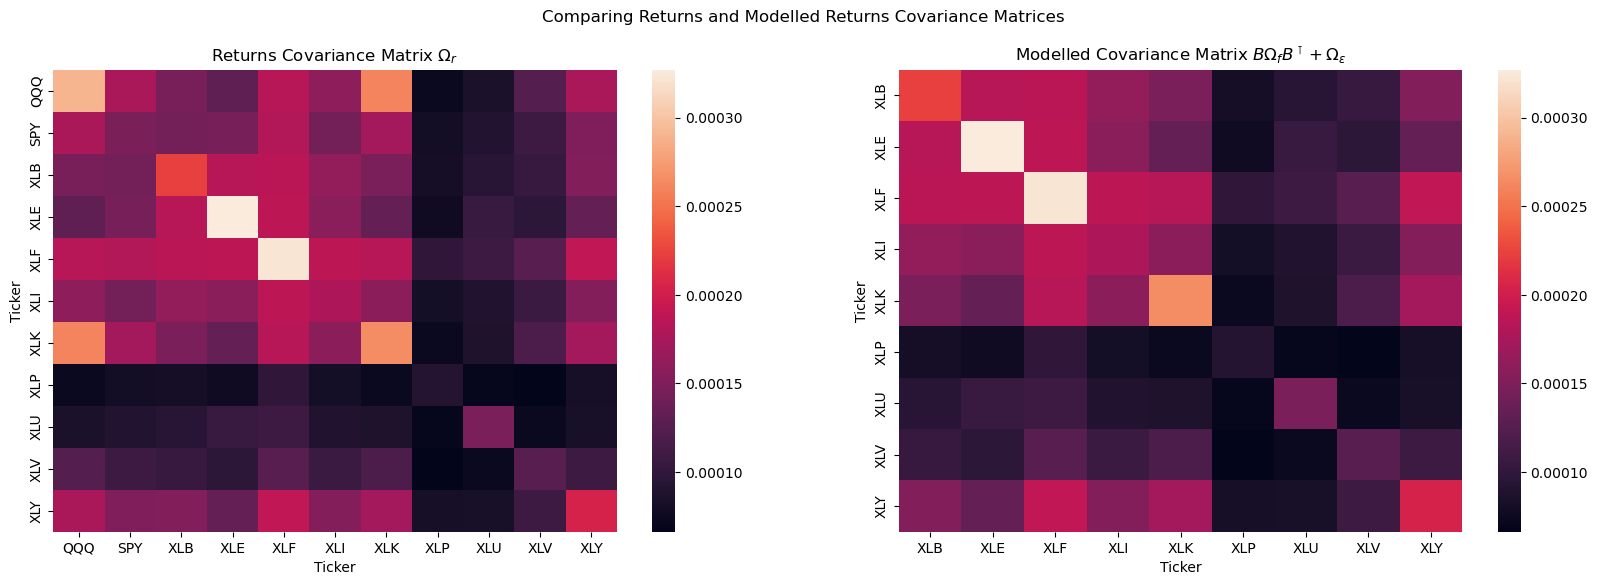

In [13]:
fig, axes = plt.subplots(ncols = 2, figsize = (20,6))

rtn_cov = (pd.DataFrame(
    data    = OmegaR,
    columns = R.columns.to_list(),
    index   = R.columns.to_list()))

sns.heatmap(
    ax   = axes[0],
    data = returns.cov())

sns.heatmap(
    data = rtn_cov,
    ax   = axes[1])

for ax in axes.flatten():
    ax.set_xlabel("Ticker")
    ax.set_ylabel("Ticker")

axes[0].set_title(r"Returns Covariance Matrix $\Omega_r$")
axes[1].set_title(r"Modelled Covariance Matrix $B\Omega_fB^\intercal + \Omega_{\epsilon}$")
fig.suptitle("Comparing Returns and Modelled Returns Covariance Matrices")
plt.show()

## 4.3 Alpha Spanned and Alpha Orthogonal

Start with using SPY and QQQ as the factors and the sector ETFs as the
individual securities. First start by running $n$ regressions for $n$ securities:
$$
r_t = \alpha + \beta f_t+ \varepsilon_t
$$
Then with the vector of $\mathbf{\alpha} \in \mathbb{R}^n$ and the matrix of loadings $\mathbf{B} \in \mathbb{R}^{n \times 2}$ (for SPY and QQQ factor), we can introduce in the idea of $\mathbf{\alpha}_{\perp}$ and $\mathbf{\alpha}_{\parallel}$ via
$$
\mathbf{\alpha} = \mathbf{\alpha}_{\perp} + \mathbf{B}\lambda 
$$
The $\lambda$ is the projection but for computational feasability it can be solved via the least squares
$$
\mathbb{\hat\lambda} = \arg\min_{\lambda \in \mathbb{R}^K} \|\mathbf{\alpha - B\lambda}\|^2
$$
Then plug in $\lambda$ with some indeterminacy 
$$
\mathbf{r_t} = \mathbf{\alpha_{\perp}} + \mathbf{B}\left( \mathbf{\lambda} + \mathbb{E}(f_t)\right) + \mathbf{B}\left(f_t - \mathbb{E}(f_t)\right)
$$

In [14]:
df_longer = (df_rtn
    .pivot(index = "date", columns = "Ticker", values = "value")
    .drop(columns = ["IYY"])
    .reset_index()
    .melt(id_vars = ["date", "SPY", "QQQ"])
    .dropna())

In [15]:
tickers = df_longer.Ticker.drop_duplicates().sort_values().to_list()

In [16]:
lam        = np.linalg.lstsq(B, alpha, rcond=None)[0]
alpha_par  = B @ lam                                 
alpha_perp = alpha - alpha_par                       

mu_f            = F.mean().values
alpha_par_meanf = B @ mu_f  

results = pd.DataFrame({
    "ticker"           : R.columns,
    "alpha"            : alpha,
    "alpha_par"        : alpha_par,
    "alpha_perp"       : alpha_perp,
    "alpha_par_meanf"  : alpha_par_meanf,
    "beta_SPY"         : B[:, 0],
    "beta_QQQ"         : B[:, 1]})

In [17]:
results

,ticker,alpha,alpha_par,alpha_perp,alpha_par_meanf,beta_SPY,beta_QQQ
0,XLB,0.000056,0.000068,-1.193162e-05,0.000354,1.329846,-0.307659
1,XLE,0.000117,0.000090,2.697307e-05,0.000344,1.623467,-0.539168
2,XLF,-0.000067,0.000087,-1.542465e-04,0.000448,1.701721,-0.404193
3,XLI,0.000060,0.000053,6.956885e-06,0.000368,1.145266,-0.148946
4,XLK,-0.000018,-0.000017,-7.426920e-07,0.000505,0.345929,0.687137
5,XLP,0.000107,0.000046,6.121616e-05,0.000190,0.836799,-0.254579
6,XLU,0.000158,0.000052,1.063773e-04,0.000218,0.950721,-0.285950
7,XLV,0.000096,0.000034,6.210107e-05,0.000278,0.780158,-0.049698
8,XLY,0.000069,0.000044,2.479423e-05,0.000392,1.050322,-0.033780


<Axes: title={'center': '$\\alpha$ from OLS Regression'}, xlabel='ticker', ylabel='$\\alpha$'>

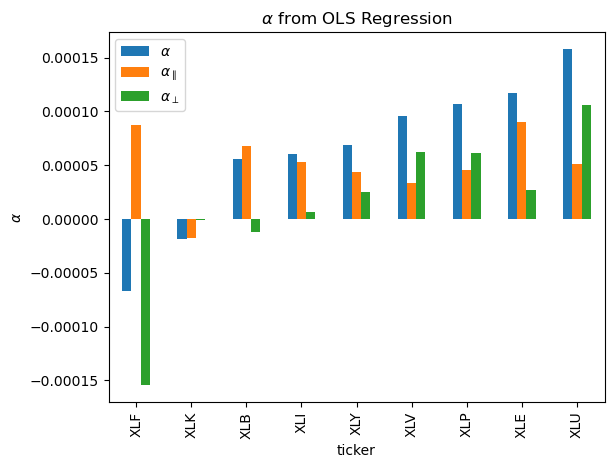

In [18]:
(results
    .set_index("ticker")
    [["alpha", "alpha_par", "alpha_perp"]]
    .sort_values(["alpha", "alpha_par", "alpha_perp"])
    .rename(columns = renamer)
    .plot(
        kind   = "bar",
        ylabel = r"$\alpha$",
        title  = r"$\alpha$" + " from OLS Regression"))

Now make a portfolio that takes a position relative to the $\alpha_{\perp}$. The resulting weights will be dollar neutral under the orthogonality constraint of $\mathbf{B}^\top \alpha_{\perp} = 0$. 
\begin{equation}
\mathbf{w}= \frac{\mathbf{\alpha_{\perp}}}{\lVert \mathbf{\alpha_{\perp}} \rVert}
\end{equation}

In [19]:
w        = alpha_perp / np.linalg.norm(alpha_perp)
port_rtn = (R @ w)

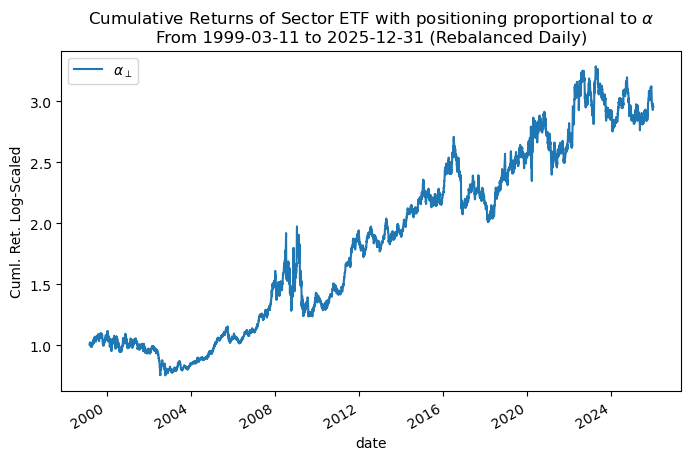

In [20]:
fig, axes = plt.subplots(figsize = (8,5))
(port_rtn
    .to_frame(name = r"$\alpha_{\perp}$")
    .apply(lambda x: np.cumprod(1 + x))
    .plot(
        ax      = axes,
        ylabel  = "Cuml. Ret. Log-Scaled",
        title   = r"Cumulative Returns of Sector ETF with positioning proportional to $\alpha$" + "\nFrom {} to {} (Rebalanced Daily)".format(
            port_rtn.index.min().date(),
            port_rtn.index.max().date())))

plt.show()

The sharpes of the portfolio

In [21]:
sharpe = port_rtn.mean() / port_rtn.std() * np.sqrt(252)
display(pd.DataFrame({
    "sharpe": [sharpe]}))

,sharpe
0,0.335497


When the weighting of the portfolio $\mathbf{w} = \mathbf{\alpha_{\perp}}/\lVert \mathbf{\alpha_{\perp}} \rVert$ leads to the following returns 
\begin{align}
\mathbf{w}^\top\mathbf{r}_t &= \left(\frac{\mathbf{\alpha_{\perp}}}{\lVert \mathbf{\alpha_{\perp}} \rVert}\right)^\top \mathbf{r_t}\\
                            &= \left(\frac{\mathbf{\alpha_{\perp}}}{\lVert \mathbf{\alpha_{\perp}} \rVert}\right)^\top (\mathbf{\alpha} + \mathbf{B}f_t + \epsilon_t) \\
                            &=
\underbrace{
    \frac{\mathbf{\alpha_{\perp}}^\top \mathbf{\alpha_{\parallel}}}
    {\lVert \mathbf{\alpha_{\perp}} \rVert}
    +
    \frac{\mathbf{\alpha_{\perp}}^\top \mathbf{\alpha_{\perp}}}
    {\lVert \mathbf{\alpha_{\perp}} \rVert}
}_{\alpha = \alpha_{\perp} + \alpha_{\parallel},\;\;\alpha_{\perp}\top\alpha_{\parallel} = 0}
+
\underbrace{
    \frac{\mathbf{\alpha_{\perp}}^\top \mathbf{B}f_t}
    {\lVert \mathbf{\alpha_{\perp}} \rVert}
}_{0 \; \text{orthogonal}}
+
\frac{\mathbf{\alpha_{\perp}}^\top \epsilon_t}
{\lVert \mathbf{\alpha_{\perp}} \rVert}\\
&= \lVert \alpha_{\perp} \rVert + \frac{\alpha_{\perp}^\top\epsilon_t}{\lVert \alpha_{\perp} \rVert}
\end{align}

That leads to some nice first and second moments which can be used to help describe the sharpe. 

\begin{align}
\mathbb{E}(\mathbf{w}^\top\mathbf{r_t}) &= \lVert \alpha_{\perp} \rVert \\
Var(\mathbf{w}^\top\mathbf{r_t})        &= \frac{\alpha_{\perp}^\top \Omega_{\epsilon} \alpha_{\perp}}{\lVert \alpha_{\perp} \rVert^2} \\
\sqrt{Var(\mathbf{w}^\top\mathbf{r_t})} &= \frac{\sqrt{\alpha_{\perp}^\top \Omega_{\epsilon} \alpha_{\perp}}}{\lVert \alpha_{\perp} \rVert}
\end{align}

In [22]:
port_mean       = port_rtn.mean()
alpha_perp_mean = np.linalg.norm(alpha_perp)
port_var        = port_rtn.var()
alpha_perp_var  = alpha_perp.T @ OmegaE @ alpha_perp / (alpha_perp.T @ alpha_perp)

(pd
    .DataFrame(
        data = {
            "mean_val" : [port_mean, alpha_perp_mean],
            "var_val"  : [port_var, alpha_perp_var]},
        index = ["From Portfolio", "From Formula"])
    .assign(
        mean_val = lambda x: x.mean_val * 252,
        var_val  = lambda x: x.var_val * np.sqrt(252))
    .rename(columns = {
        "mean_val": "Avg. Rtn",
        "var_val" : "Var. Rtn"}))

,Avg. Rtn,Var. Rtn
From Portfolio,0.053007,0.001573
From Formula,0.053007,0.001573


In [23]:
omega_epsilon = np.cov(E, rowvar = False)

These have interseting properties when applying them to sharpe ratios. 
\begin{align}
SR  &= \frac{\mathbb{E}(\mathbf{w}^\intercal \mathbf{r}_t)}{\sqrt{\textrm{Var}(\mathbf{w}^\intercal \mathbf{r}_t)}} \\
    &= \frac{\lVert \alpha_{\perp} \rVert^2}{\sqrt{\alpha_{\perp}^\intercal \Omega_{\epsilon} \alpha_{\perp}}}
\end{align}
The $\alpha_{\perp}^\intercal \Omega_{\epsilon} \alpha_{\perp}$ can be expressed via operator norm 
\begin{align}
\alpha_{\perp}^\intercal \Omega_{\epsilon} \alpha_{\perp} &\leq \lVert \Omega_{\epsilon} \rVert \cdot \lVert \alpha_{\perp}^2 \rVert \\
\sqrt{\alpha_{\perp}^\intercal \Omega_{\epsilon} \alpha_{\perp}} &\leq \sqrt{\lVert \Omega_{\epsilon} \rVert} \cdot \lVert \alpha_{\perp} \rVert 
\end{align}
Plugging that back in yields
\begin{align}
SR &= \frac{\lVert \alpha_{\perp} \rVert^2}{\sqrt{\alpha_{\perp}^\intercal \Omega_{\epsilon} \alpha_{\perp}}} \geq \frac{\lVert \alpha_{\perp} \rVert}{\sqrt{\lVert \Omega_{\epsilon} \rVert} }
\end{align}

In [24]:
(pd
    .DataFrame(
        data = {
            "avg_rtn": [np.linalg.norm(alpha_perp) ** 2, np.linalg.norm(alpha_perp)],
            "avg_std": [np.sqrt(alpha_perp.T @ OmegaE @ alpha_perp), np.sqrt(np.linalg.norm(OmegaE))]},
        index = ["left_hand", "right_hand"])
    .assign(sharpe = lambda x: x.avg_rtn / x.avg_std * np.sqrt(252))
    .rename(columns = {
        "avg_rtn": "Avg Rtn",
        "avg_std": "Avg Std",
        "sharpe" : "Ann. Sharpe"})
    .T
    .rename(columns = {"left_hand": "Left Hand", "right_hand": "Right Hand"})
    .apply(lambda x: np.round(x,4)))

,Left Hand,Right Hand
Avg Rtn,0.0000,0.0002
Avg Std,0.0000,0.0158
Ann. Sharpe,0.3355,0.2117


In [25]:
# Custom annotation function
def annotate_diagonal(data, mask, ax):
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            if mask[i, j]:
                ax.text(
                    j + 0.5,
                    i + 0.5,
                    f'{data[i, j]:.2e}',
                    ha='center',
                    va='center',
                    color='black'
                )

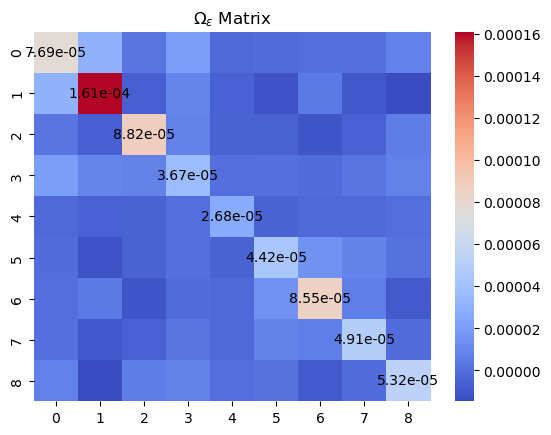

In [26]:
ax   = sns.heatmap(omega_epsilon, annot=False, cmap='coolwarm')
mask = np.zeros_like(omega_epsilon, dtype=bool)
np.fill_diagonal(mask, True)


annotate_diagonal(omega_epsilon, mask, ax)

ax.set_title(r"$\Omega_{\epsilon}$ Matrix")
plt.show()

We found a trick to get the portfolio volatility into nicer terms via operator norm and there is a way to make the expected returns (in our sharpe calculation) into a nicer form. Start by taking the average of $\alpha_\perp$ and applying 1-norm and Euclidean norm innequality
\begin{align}
\frac{1}{n}\sum_{i=1}^n |\alpha_{\perp,i}| = \mu
\end{align}
using this relationship
\begin{align}
\lVert \alpha_{\perp} \rVert_1 = \sum_{i=1}^n |\alpha_{\perp, i}|
\end{align}
Then using those two equalities leads to the following
\begin{align}
\frac{1}{n} \lVert \alpha_{\perp} \rVert_1 &= \mu \\ 
\lVert \alpha_\perp \rVert                 &= n \mu \\ 
\lVert \alpha_{\perp} \rVert_1 &\leq \sqrt{n} \lVert \alpha_{\perp} \rVert_2\\
\downarrow \\
n \mu &\leq \sqrt{n} \lVert \alpha_{\perp} \rVert_2 \\
\sqrt{n} \mu &\leq \lVert \alpha_{\perp} \rVert_2
\end{align}
This leads us to the follow inequalities with the sharpe ratios
\begin{align}
SR = \frac{\lVert \alpha_{\perp}^2 \rVert}{\sqrt{\alpha_{\perp}^\intercal \Omega_{\epsilon} \alpha_{\perp}}} \geq \frac{\lVert \alpha_{\perp} \rVert}{\sqrt{\lVert \Omega_{\epsilon} \rVert}} \geq \frac{\sqrt{n} \mu}{\sqrt{\lVert \Omega_{\epsilon} \rVert}}
\end{align}

## 4.4 Transformations

This section focuses on manipulating the matrix for the distribution 
\begin{align}
\mathbf{r} = \mathbf{\alpha} + \mathbf{\beta} + \mathbf{\epsilon}
\end{align}
Then using a transformation that does $\mathbf{\tilde{\beta}} = \mathbf{\beta C}^{-1}$ and $\mathbf{\tilde{f}} = \mathbf{Cf}$. Then we can pick different manipulations to give us different results. 

For the identity factor covariance matrix we are picking a transformation that results in $\tilde{\Omega}_f= I$. To do that we need to use singular value decomposition to get $\Omega_f = USU^\intercal$ and use this manipulation $C = S^{-1/2}U^T$

In [33]:
OmegaF           = F.cov().to_numpy()
eigvals, eigvecs = np.linalg.eigh(OmegaF)
C                = eigvecs @ np.diag(1 / np.sqrt(eigvals)) @ eigvecs.T

In [35]:
F_tilde = F.to_numpy() @ C.T

In [37]:
B_tilde = B @ np.linalg.inv(C)

In [41]:
E_tilde = (R.to_numpy() - alpha - F_tilde @ B_tilde.T)

In [42]:
np.max(np.abs(E - E_tilde))

np.float64(5.551115123125783e-17)

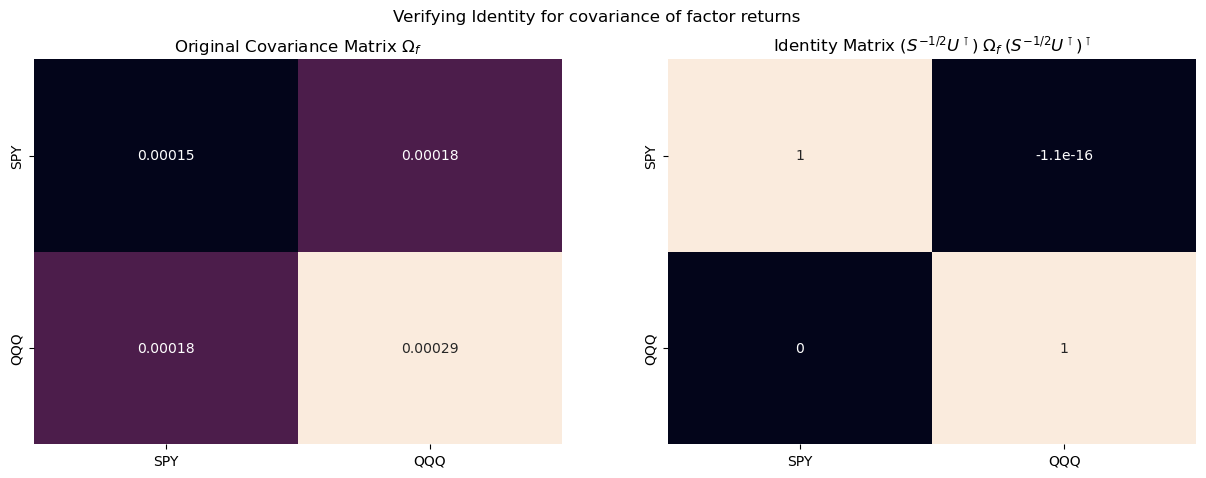

In [81]:
I = C @ OmegaF @ C.T
fig, axes = plt.subplots(ncols = 2, figsize = (15,5))

ticks = F.columns.to_list()

sns.heatmap(
    ax = axes[0],
    data = OmegaF,
    annot = True,
    cbar  = False,
    xticklabels = ticks,
    yticklabels = ticks)

sns.heatmap(
    ax          = axes[1],
    data        = I,
    annot       = True,
    cbar        = False,
    xticklabels = ticks,
    yticklabels = ticks)

axes[0].set_title(r"Original Covariance Matrix $\Omega_f$")
axes[1].set_title(r"Identity Matrix $(S^{-1/2}U^\intercal) \; \Omega_f \; (S^{-1/2}U^\intercal)^\intercal$")
fig.suptitle("Verifying Identity for covariance of factor returns")
plt.show()

<Axes: >

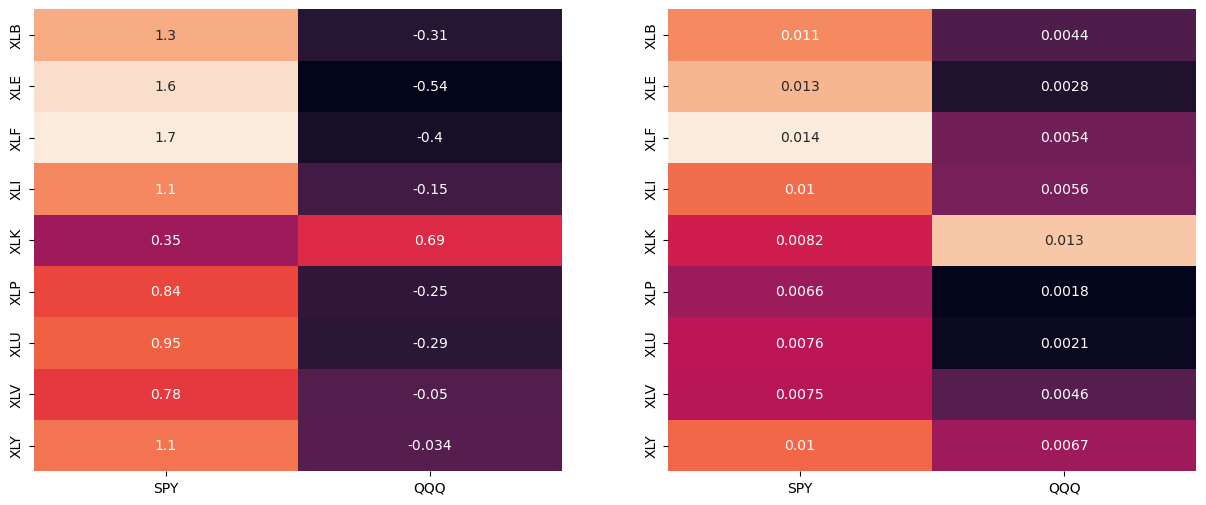

In [95]:
fig, axes   = plt.subplots(ncols = 2, figsize = (15,6))
stock_ticks = R.columns.to_list()

(sns.heatmap(
    ax          = axes[0],
    data        = B,
    cbar        = False,
    xticklabels = ticks,
    yticklabels = stock_ticks,
    annot       = True))

(sns.heatmap(
    ax          = axes[1],
    data        = B_tilde,
    cbar        = False,
    xticklabels = ticks,
    yticklabels = stock_ticks,
    annot       = True))

axes[0].set_title("Factor Loading Matrix $\Beta$")
axes[1].set_title("Factor Loading Matrix with ")

['XLB', 'XLE', 'XLF', 'XLI', 'XLK', 'XLP', 'XLU', 'XLV', 'XLY']